![title](imagens/M11_knn.jpg)

# Projeto 15 - Câncer de Mama -  KNN (K-Nearest Neighbors)

#### Vamos utilizar o dataset WBC - Wisconsis breast cancer (Câncer de Mama de Wisconsis)...

Para exemplificarmos a utilização do algoritmo de Classificação kNN (k-Nearest Neighbors) ou os k-Vizinhos mais próximos, vamos trabalhar com um data set original de Câncer de Mama de Winsconsis, disponível no site Kaggle: https://www.kaggle.com/datasets/zzero0/uci-breast-cancer-wisconsin-original/.

Esse dataset de (WBC - Wisconsin breast cancer) consiste em 699 instâncias com 10 colunas de atributos e uma coluna de classe. A coluna de classe tem duas classes, sendo quatro (maligno), que é 65,5% do total, e dois (benigno) contribuindo com 34,5%.

Os atributos são os seguintes (os valores entre parênteses corresponde aos intervalo de valores possíveis para cada atributo):

- 1 Sample code number id number - númro de código de amostra (Special Id Number)
- 2 Clump thickness - espessura do aglomerado (1-10)
- 3 Uniformity of cell size - uniformidade do tamanho celular - (1-10)
- 4 Uniformity of cell shape - uniformidade da forma celular - (1-10)
- 5 Marginal adhesion - adesão marginal - (1-10)
- 6 Single epithelial cell size - tamanho de célular epitelial única - (1-10)
- 7 Bare nuclei - núcleos desnudos - (1-10)
- 8 Bland chromatin - cromatina branda - (1-10)
- 9 Normal nucleoli - nucléolos normais - (1-10)
- 10 Mitoses - mitoses - (1-10)
- 11 Class - classe (2 'benign' and 4 'malignant' - 2 para benígno e 4 p/ malígno)

### Descrição do Problema

Com base nas variáveis independentes (de entrada - 2 a 10), teremos que construir um modelo que classifique com acurácia o tipo de câncer: Benigno (2) ou Malígno (4). Existem 699 registros.

Vamos fazer carregar o dataset, analisá-lo, fazer os ajustes necessários e então, criar o modelo utilizado o algoritmo de classificação kNN.


In [1]:
# Versão da Linguagem Python
from platform import python_version
print('Versão da Linguagem Python usada neste Projeto no Jupyter Notebook:', python_version())

Versão da Linguagem Python usada neste Projeto no Jupyter Notebook: 3.11.7


In [2]:
# Para atualizar um pacote, execute o comando abaixo no terminal ou prompt de comando:
# pip install -U nome_pacote

# Para instalar a versão exata de um pacote, execute o comando abaixo no terminal ou prompt de comando:
# !pip install nome_pacote==versão_desejada

# Depois de instalar ou atualizar o pacote, reinicie o jupyter notebook.

# Instala o pacote watermark. 
# Esse pacote é usado para gravar as versões de outros pacotes usados neste jupyter notebook.
# !pip install -q -U watermark

### Importando bibliotecas

In [4]:
# Os pacotes tradicionais
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

# os pacotes para criação do modelo / aprendizagem de máquina
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

# para evitar mensagens de alerta/warnings.
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Carregar o módulo de funções para limpeza de dados
from limpeza_dados import *

In [5]:
# Versões dos pacotes usados neste jupyter notebook
%reload_ext watermark
%watermark -a "pyPRO - Seja um Profissional Python!" --iversions

Author: pyPRO - Seja um Profissional Python!

pandas    : 2.2.2
numpy     : 1.26.4
seaborn   : 0.13.2
matplotlib: 3.8.4



### Obtendo os dados

In [6]:
data = 'dados/breast-cancer-wisconsin.data.txt'
df = pd.read_csv(data, header=None)

In [7]:
# dimensões do dataset
df.shape

(699, 11)

In [8]:
# Observando co cabeçalho do dataset
df.head()

,0,1,2,3,4,5,6,7,8,9,10
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


Vamos renomear o nome das colunas para aqueles que descrevemos acima. Note que temos 11 colunas (inicia com zero).

In [9]:
# Criando uma lista com o nome dos campos. Mantivemos os nomes em inglês para 
col_names = ['Id', 'Clump_thickness', 'Uniformity_Cell_Size', 'Uniformity_Cell_Shape', 'Marginal_Adhesion', 
             'Single_Epithelial_Cell_Size', 'Bare_Nuclei', 'Bland_Chromatin', 'Normal_Nucleoli', 'Mitoses', 'Class']
# Definindo os novos nomes
df.columns = col_names
df.columns

Index(['Id', 'Clump_thickness', 'Uniformity_Cell_Size',
       'Uniformity_Cell_Shape', 'Marginal_Adhesion',
       'Single_Epithelial_Cell_Size', 'Bare_Nuclei', 'Bland_Chromatin',
       'Normal_Nucleoli', 'Mitoses', 'Class'],
      dtype='object')

In [10]:
df.head()

,Id,Clump_thickness,Uniformity_Cell_Size,Uniformity_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


#### Excluir colunas redundantes
Devemos excluir quaisquer colunas redundantes do conjunto de dados que não possuem poder preditivo. Aqui, o Id é a coluna redundante.

Portanto, vamos excluí-la.





In [11]:
# excluindo a coluna ID do dataset

df.drop('Id', axis=1, inplace=True)

In [12]:
df.head()

,Clump_thickness,Uniformity_Cell_Size,Uniformity_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
0,5,1,1,1,2,1,3,1,1,2
1,5,4,4,5,7,10,3,2,1,2
2,3,1,1,1,2,2,3,1,1,2
3,6,8,8,1,3,4,3,7,1,2
4,4,1,1,3,2,1,3,1,1,2


### Exploração dos Dados (EDA)

In [13]:
# Vamos ver um sumário do dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Clump_thickness              699 non-null    int64 
 1   Uniformity_Cell_Size         699 non-null    int64 
 2   Uniformity_Cell_Shape        699 non-null    int64 
 3   Marginal_Adhesion            699 non-null    int64 
 4   Single_Epithelial_Cell_Size  699 non-null    int64 
 5   Bare_Nuclei                  699 non-null    object
 6   Bland_Chromatin              699 non-null    int64 
 7   Normal_Nucleoli              699 non-null    int64 
 8   Mitoses                      699 non-null    int64 
 9   Class                        699 non-null    int64 
dtypes: int64(9), object(1)
memory usage: 54.7+ KB


Podemos ver que a coluna ID foi removida do conjunto de dados.

Podemos ver que há 9 variáveis numéricas e 1 variável categórica no conjunto de dados

Vamos verificar a distribuição de e frequência dos valores nas variáveis para confirmar o mesmo.

In [14]:
# verificando a distribuição de frequência em todas as colunas do dataset
for var in df.columns:
    print(df[var].value_counts())

Clump_thickness
1     145
5     130
3     108
4      80
10     69
2      50
8      46
6      34
7      23
9      14
Name: count, dtype: int64
Uniformity_Cell_Size
1     384
10     67
3      52
2      45
4      40
5      30
8      29
6      27
7      19
9       6
Name: count, dtype: int64
Uniformity_Cell_Shape
1     353
2      59
10     58
3      56
4      44
5      34
6      30
7      30
8      28
9       7
Name: count, dtype: int64
Marginal_Adhesion
1     407
3      58
2      58
10     55
4      33
8      25
5      23
6      22
7      13
9       5
Name: count, dtype: int64
Single_Epithelial_Cell_Size
2     386
3      72
4      48
1      47
6      41
5      39
10     31
8      21
7      12
9       2
Name: count, dtype: int64
Bare_Nuclei
1     402
10    132
2      30
5      30
3      28
8      21
4      19
?      16
9       9
7       8
6       4
Name: count, dtype: int64
Bland_Chromatin
2     166
3     165
1     152
7      73
4      40
5      34
8      28
10     20
9      11
6      10
N

A distribuição dos valores mostra que o tipo de dados de Bare_Nuclei é do tipo inteiro. Mas o resumo do dataframe mostra que é do tipo objeto. 

Portanto, vamos converter explicitamente seu tipo de dados para inteiro.

In [15]:
df['Bare_Nuclei'] = pd.to_numeric(df['Bare_Nuclei'], errors='coerce')

Verificando os tipos de dados do dataframe

In [16]:
df.dtypes

Clump_thickness                  int64
Uniformity_Cell_Size             int64
Uniformity_Cell_Shape            int64
Marginal_Adhesion                int64
Single_Epithelial_Cell_Size      int64
Bare_Nuclei                    float64
Bland_Chromatin                  int64
Normal_Nucleoli                  int64
Mitoses                          int64
Class                            int64
dtype: object

Agora podemos ver que todas as colunas do dataframe são numéricas!

#### Valores ausentes
Vamos dar uma olhada agora para verificar se existe algum valor ausente em nosso dataset

In [17]:
# verificando se existe algum valor nulo
calcular_porcentagem_valores_ausentes(df)

O conjunto de dados tem 0.23% de valores ausentes.


In [18]:
# Exibindo o relatório de valores nulos por coluna
relatorio_valores_ausentes_por_coluna(df)

O conjunto de dados tem 10 colunas. 
Foram encontradas 1 colunas com valores ausentes.


,Quantidade de Ausentes,Porcentagem de Ausentes,Tipo de Dado
Bare_Nuclei,16,2.29,float64


Vamos ver que tipo de valor ausente a coluna 'Bare_Nuclei' tem...

In [19]:
df['Bare_Nuclei'].unique()

array([ 1., 10.,  2.,  4.,  3.,  9.,  7., nan,  5.,  8.,  6.])

Podemos ver que os valores ausentes dessa coluna são 'nan'

Vamos verificar o quanto esses valores nulos correspondem ao total do dataset...

In [20]:
# Exibindo o relatório de valores nulos por coluna
relatorio_valores_ausentes_por_coluna(df)

O conjunto de dados tem 10 colunas. 
Foram encontradas 1 colunas com valores ausentes.


,Quantidade de Ausentes,Porcentagem de Ausentes,Tipo de Dado
Bare_Nuclei,16,2.29,float64


Um pouco mais de 2% dos valores... Vamos fazer recorrer a estratégia de imputação de valores.

In [21]:
# este código percorre todo o dataframe e, para cada coluna com valores ausentes, calcula a média e faz 
# a imputação dos valores ausentes com esse valor.
for col in df.columns:
    if df[col].isnull().mean() > 0:
        mean_value = df[col].mean()
        df[col].fillna(mean_value, inplace=True)

In [22]:
# verificando se existe algum valor nulo
calcular_porcentagem_valores_ausentes(df)

O conjunto de dados tem 0.0% de valores ausentes.


Perfeito!!  Vamos agora verificar a distribuição de frequência dos dois valores da coluna "Class"

In [23]:
df['Class'].value_counts()/float(len(df))

Class
2    0.655222
4    0.344778
Name: count, dtype: float64

34,47% de Malignidade e 65,52% de Benignidade. Essa é a distribuição dos tipos de Câncer de Mama encontrados no dataset

Vamos verificar se existem outliers (valores que estrapolam muito da média dos valores do dataset)

In [24]:
print(round(df.describe(),2))

       Clump_thickness  Uniformity_Cell_Size  Uniformity_Cell_Shape  \
count           699.00                699.00                 699.00   
mean              4.42                  3.13                   3.21   
std               2.82                  3.05                   2.97   
min               1.00                  1.00                   1.00   
25%               2.00                  1.00                   1.00   
50%               4.00                  1.00                   1.00   
75%               6.00                  5.00                   5.00   
max              10.00                 10.00                  10.00   

       Marginal_Adhesion  Single_Epithelial_Cell_Size  Bare_Nuclei  \
count             699.00                       699.00       699.00   
mean                2.81                         3.22         3.54   
std                 2.86                         2.21         3.60   
min                 1.00                         1.00         1.00   
25%       

### Visualização dos Dados

Vamos checar a distribuição das variáveis...
Vamos plotar os histogramas para verificar as distribuições das variáveis para descobrir se elas são normais ou assimétricas.

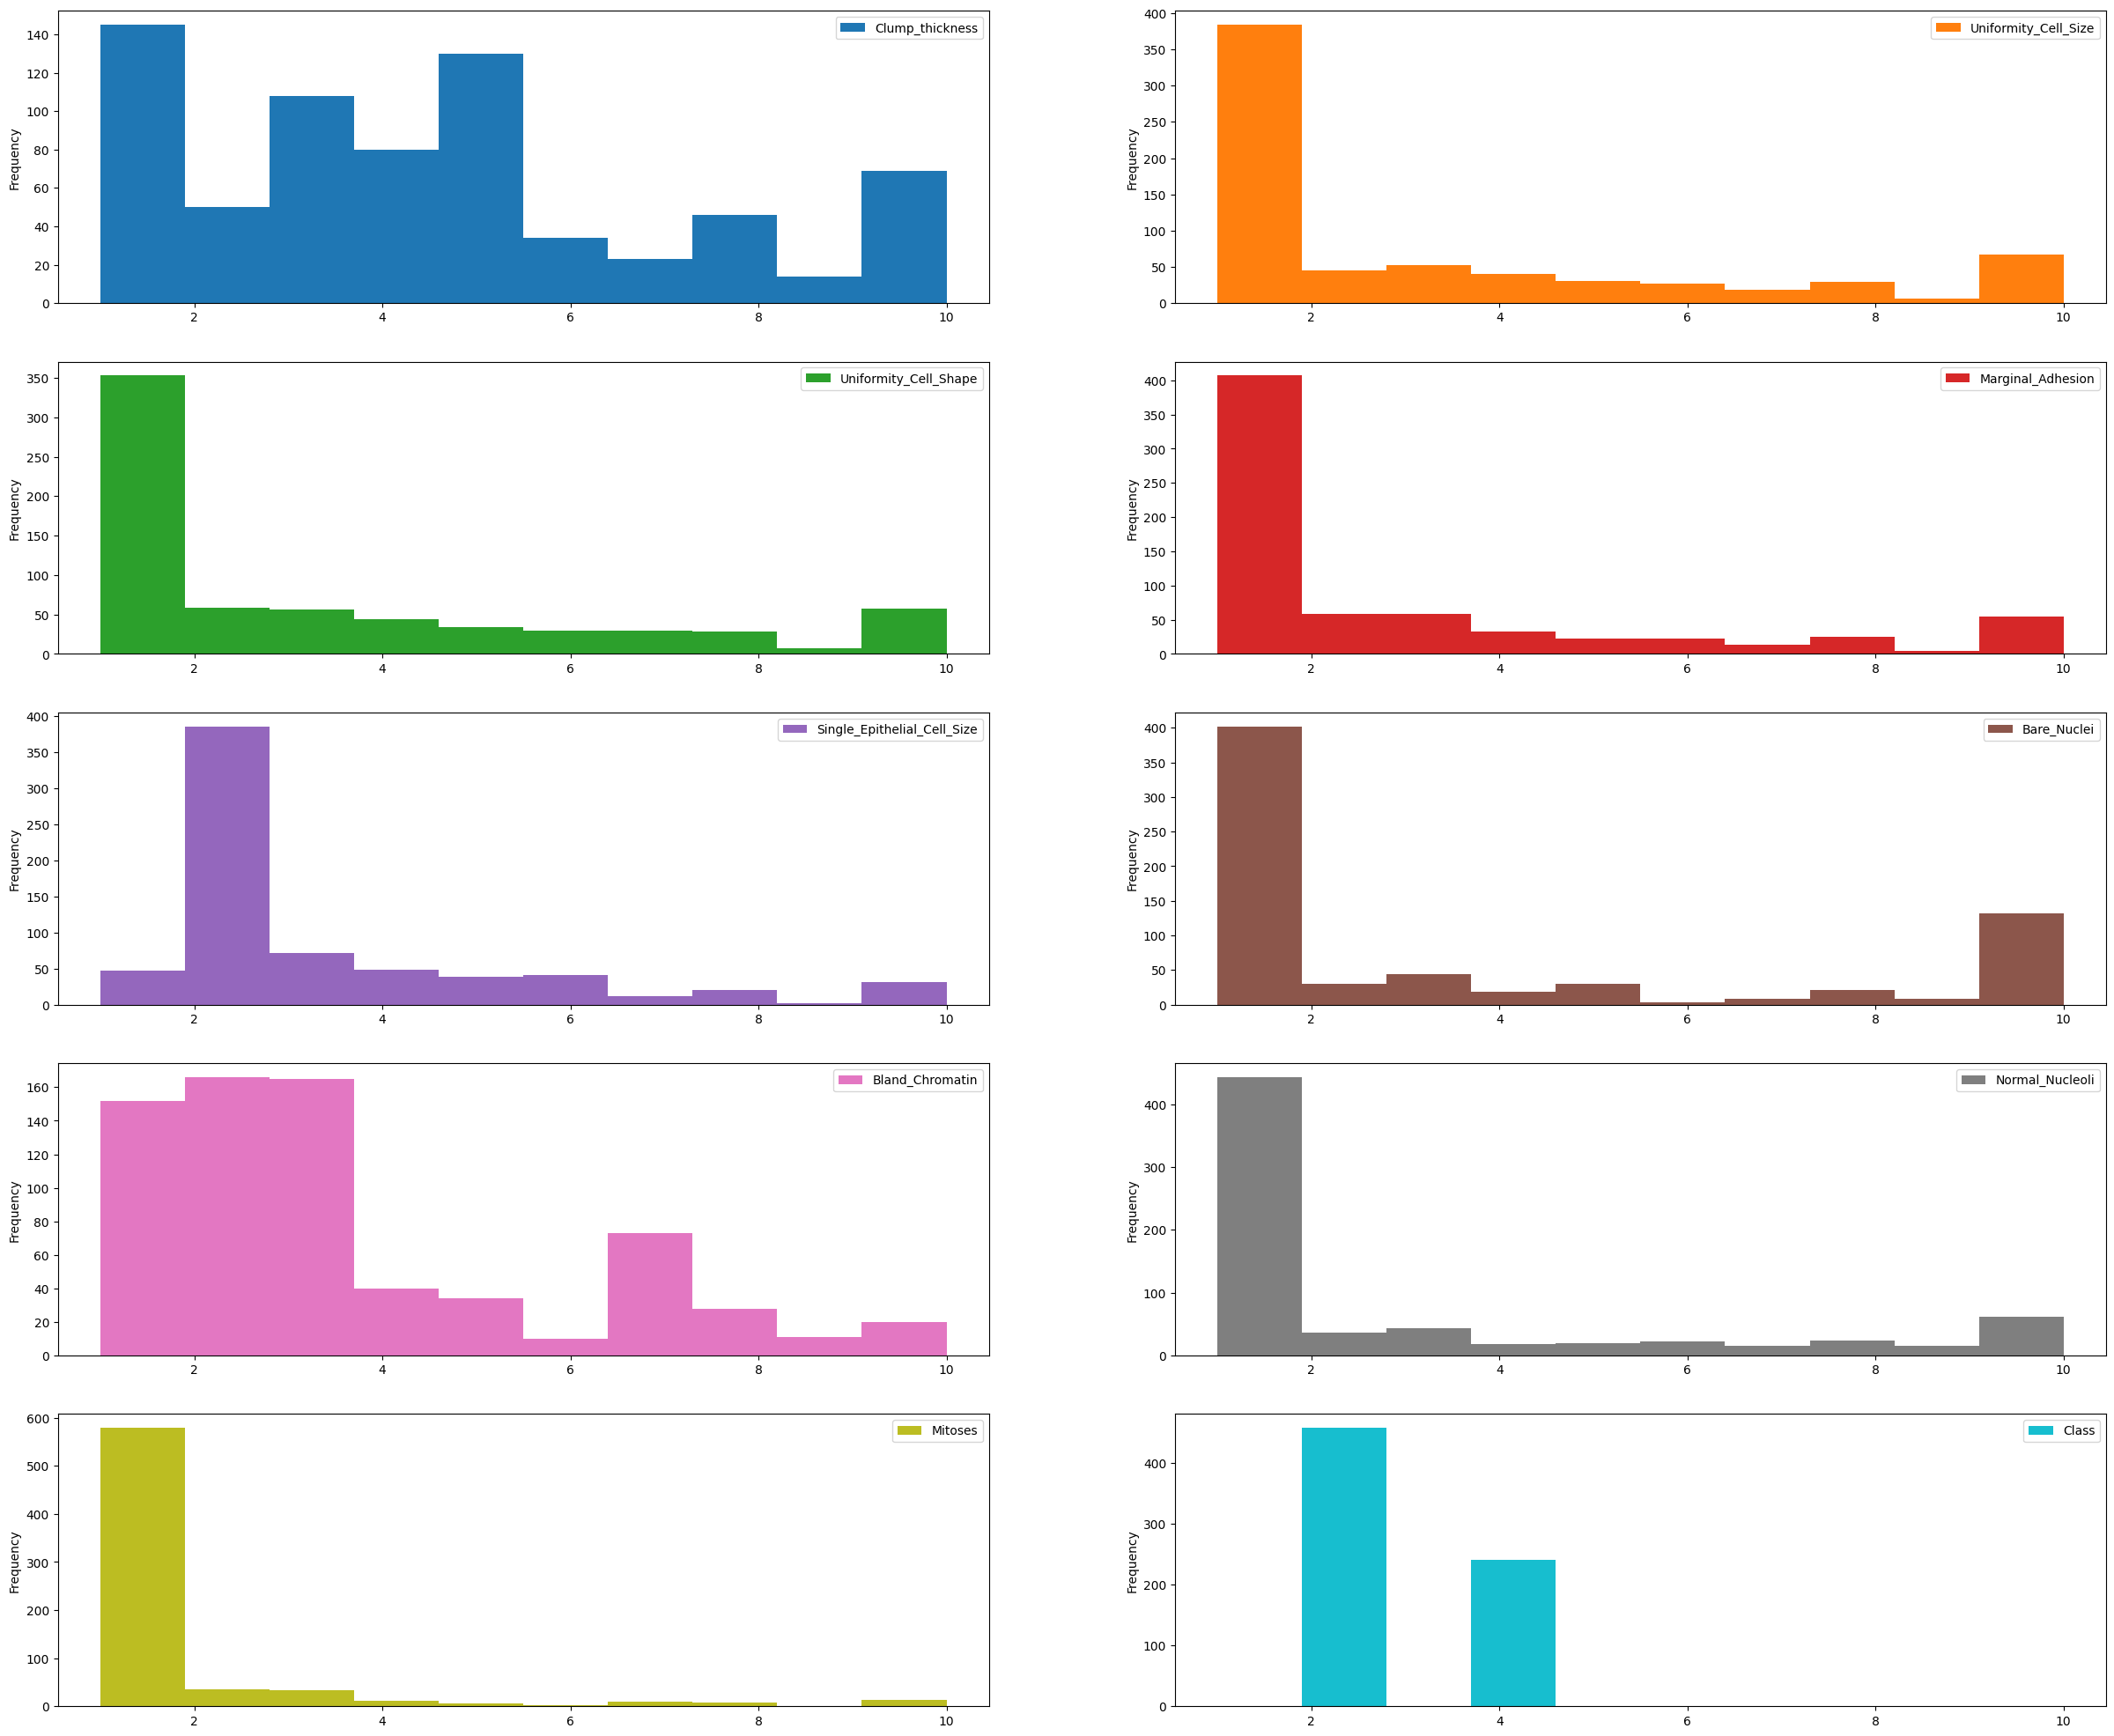

In [25]:
plt.rcParams['figure.figsize']=(30,25)
df.plot(kind='hist', bins=10, subplots=True, layout=(5,2), sharex=False, sharey=False)
plt.show()

Podemos ver que todas as variáveis no conjunto de dados têm assimetria positiva.

Quando uma distribuição é assimétrica, significa que ela não é simétrica em relação ao seu ponto central.

A assimetria positiva, também chamada de assimetria para a direita, ocorre quando a cauda direita da distribuição é mais longa ou mais espalhada do que a cauda esquerda. Isso significa que há mais valores concentrados no lado esquerdo do ponto central e menos valores estendidos para a direita.

Em termos práticos, uma distribuição com assimetria positiva tende a ter a média (ou média aritmética) maior do que a mediana e a moda. Isso ocorre porque os valores extremamente altos na cauda direita afetam a média, mas não tanto a mediana ou a moda.

**Estimando coeficientes de correlação**
Nosso conjunto de dados é muito pequeno. Portanto, podemos calcular o coeficiente de correlação padrão (também chamado de r de Pearson) entre cada par de atributos. Podemos calculá-lo usando o método df.corr() da seguinte maneira:

In [26]:
correlation = df.corr()

Nossa variável alvo é a 'Class'. Portanto, devemos verificar como cada atributo se correlaciona com a variável 'Class'. 

Podemos fazer isso da seguinte maneira:

In [27]:
correlation['Class'].sort_values(ascending=False)

Class                          1.000000
Uniformity_Cell_Shape          0.818934
Uniformity_Cell_Size           0.817904
Bare_Nuclei                    0.816050
Bland_Chromatin                0.756616
Clump_thickness                0.716001
Normal_Nucleoli                0.712244
Marginal_Adhesion              0.696800
Single_Epithelial_Cell_Size    0.682785
Mitoses                        0.423170
Name: Class, dtype: float64

**Interpretação**
O coeficiente de correlação varia de -1 a +1.

Quando está próximo de +1, isso significa que há uma forte correlação positiva. Portanto, podemos ver que há uma forte correlação positiva entre Casse e Bare_Nuclei, Casse e Uniformity_Cell_Shape, Casse e Uniformity_Cell_Size.

Quando está próximo de -1, significa que há uma forte correlação negativa. Quando está próximo de 0, significa que não há correlação.

Podemos ver que todas as variáveis estão positivamente correlacionadas com a variávl Classe. Algumas variáveis têm forte correlação positiva, enquantofraca correlação positivanegativa.

Vamos ver agora o mapa de correlação (graficamente)

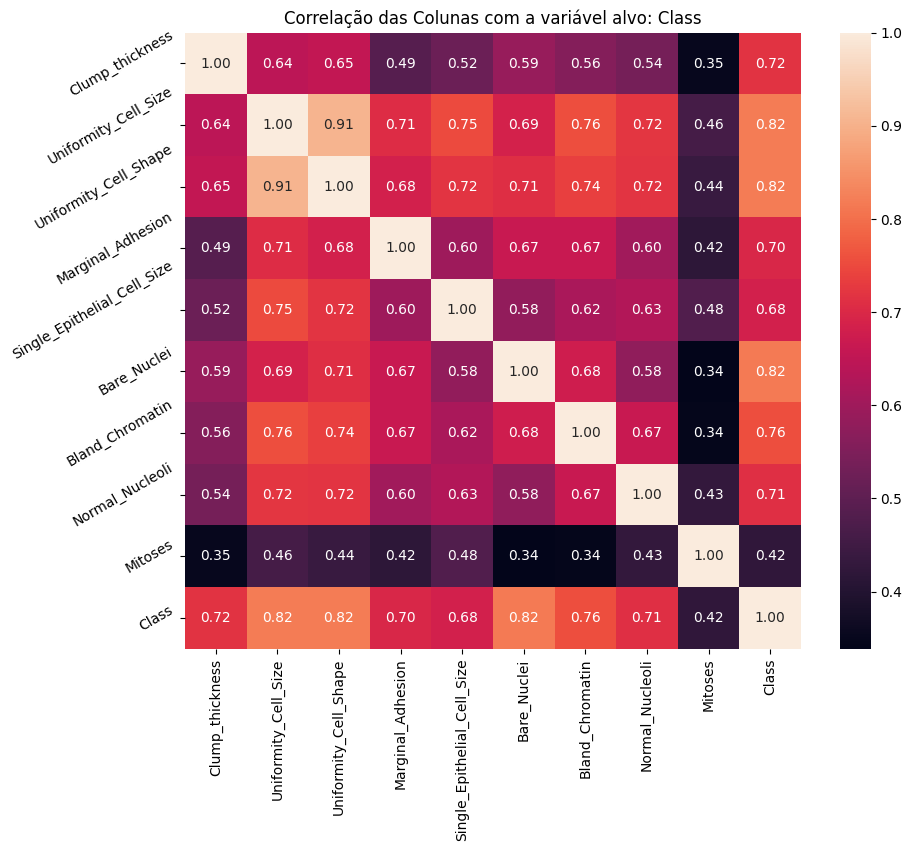

In [28]:
plt.figure(figsize=(10,8))
plt.title('Correlação das Colunas com a variável alvo: Class')
a = sns.heatmap(correlation, square=True, annot=True, fmt='.2f', linecolor='white')
a.set_xticklabels(a.get_xticklabels(), rotation=90)
a.set_yticklabels(a.get_yticklabels(), rotation=30)           
plt.show()

**Interpretação**
A partir do mapa de calor de correlação acima, podemos concluir que:

Clsse está altamente positivamente correlacionada com Uniformity_Cell_Size, Uniformity_Cell_Shape e Bare_Nuclei (coeficiente de correlação = 0,82).

Classe está positivamente correlacionada com Clump_thickness (coeficiente de correlação = 0,72), Marginal_Adhesion (coeficiente de correlação = 0,70), Single_Epithelial_Cell_Size (coeficiente de correlação = 0,68) e Normal_Nucleoli (coeficiente de correlação = 0,71).

Classe está fracamente pvamente correlacionada com Mitoses (coeficiente de correlação = 0,42).

A variável Mitoses está fracamente positivamente correlacionada com todas as outras variáveis (coeficiente de correlação < 0,50).

### Divisão em Teste e Treino

In [29]:
# Divisão das variáveis independentes (x) da variável dependente (y)
X = df.drop(['Class'], axis=1)
y = df['Class']

In [30]:
# Dividindo X e y em treino e teste na proporção de 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [31]:
# vamos checar como ficaram as divisões
X_train.shape, X_test.shape

((559, 9), (140, 9))

### Padronização da Escala de Valores

Antes de criar o modelo, precisamos colocar os valores em uma mesma escala, para que não haja problemas na criação do modelo.

In [32]:
cols = X_train.columns
# Vamos utilizar a função pronta no pacote Sklearn de Padronização de Escala (StandardScaler())
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Apenas para entender o que essa função fez... vamos pegar os dados de treinamento, convertêlos para um dataframe e então exibir alguns dados para verificar como foi feita a padronização.

In [33]:
X_train = pd.DataFrame(X_train, columns=[cols])
X_train.head()

,Clump_thickness,Uniformity_Cell_Size,Uniformity_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses
0,2.028383,0.299506,0.289573,1.119077,-0.546543,1.851518,-0.577774,0.041241,-0.324258
1,1.669451,2.257680,2.304569,-0.622471,3.106879,1.287781,-0.159953,0.041241,-0.324258
2,-1.202005,-0.679581,-0.717925,0.074148,-1.003220,-0.121562,-0.995595,-0.608165,-0.324258
3,-0.125209,-0.026856,-0.046260,-0.622471,-0.546543,-0.685299,-0.159953,0.041241,-0.324258
4,0.233723,-0.353219,-0.382092,-0.274161,-0.546543,-0.685299,-0.577774,-0.283462,-0.324258


Agora já podemos criar o modelo, utilizando, neste caso o algoritmo kNN...

### Criando o Modelo com kNN

In [34]:
# instanciando o modelo, utilizando a classe disponível no pacote sklearn: kNeighborsClassifier.
# veja que temos que passar como parâmetro o número de visinhos a serem utilizados... vamos começar com k=3
knn = KNeighborsClassifier(n_neighbors=3)

# Fazendo o treinamento com base no conjunto de treinamento (X_train)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

### Predição e Avaliação

In [35]:
# Predição
y_pred = knn.predict(X_test)
y_pred

# Avaliação... Verificando a Acurácia:
print(f'Acurácia do Modelo: {accuracy_score(y_test, y_pred):0.4f}')

Acurácia do Modelo: 0.9714


Para verificarmos se não ocorreu overfitting, podemos checar a acurácia entre os modelos de treinamento e teste.

In [36]:
print(f'Acurácia do Treinamento: {knn.score(X_train, y_train):.4f}')
print(f'Acurácia do Teste......: {knn.score(X_test, y_test):.4f}')

Acurácia do Treinamento: 0.9785
Acurácia do Teste......: 0.9714


Como podem perceber... não existe dúvidas sobre overfitting. Está ótimo o nosso modelo. Mas será que podemos melhorar?

### Recriando o Modelo usando diferentes valores de K

#### Recriando o Classificador kNN agora com k=5

In [37]:
# Instanciando o modelo com k=5
knn_5 = KNeighborsClassifier(n_neighbors=5)

# treinando o modelo
knn_5.fit(X_train, y_train)

# Fazendo a Predição
y_pred_5 = knn_5.predict(X_test)

# Imprimindo a acurácia do modelo
print(f'Acurácia do modelo com k = 5: {accuracy_score(y_test, y_pred_5):0.4f}')

Acurácia do modelo com k = 5: 0.9714


#### Recriando o Classificador kNN agora com k=7

In [38]:
# Instanciando o modelo com k=7
knn_7 = KNeighborsClassifier(n_neighbors=7)

# treinando o modelo
knn_7.fit(X_train, y_train)

# Fazendo a Predição
y_pred_7 = knn_7.predict(X_test)

# Imprimindo a acurácia do modelo
print(f'Acurácia do modelo com k = 7: {accuracy_score(y_test, y_pred_7):0.4f}')

Acurácia do modelo com k = 7: 0.9786


#### Recriando o Classificador kNN agora com k=9

In [39]:
# Instanciando o modelo com k=5
knn_9 = KNeighborsClassifier(n_neighbors=9)

# treinando o modelo
knn_9.fit(X_train, y_train)

# Fazendo a Predição
y_pred_9 = knn_9.predict(X_test)

# Imprimindo a acurácia do modelo
print(f'Acurácia do modelo com k = 9: {accuracy_score(y_test, y_pred_9):0.4f}')

Acurácia do modelo com k = 9: 0.9714


**Interpretação**

Nosso índice de precisão original do modelo com k=3 é 0.9714. Agora, podemos ver que alcançamos o mesmo índice de precisão de 0.9714 com k=5. No entanto, se aumentarmos o valor de k ainda mais, isso resultará em uma precisão aprimorada

Co7,7,8, alcançamos um índice de precisão de 0.9786. Portanto, isso resulta em melhoria de desempeno.

Se aumentarmos k para 9, então a precisão diminui novamente para 0.714.

Agora, com base na análise acima, podemos concluir que a precisão do nosso modelo de classificação é muito boa. Nosso modelo está fazendo um trabalho muito bom em termos de prever os rótulos das casses.

No entanto, ele não fornece a distribuição subjacente dos valores. Além disso, não nos diz nada sobre o tipo de erros que nosso classificador está cmetendo.

Temos outra ferramenta chamada matriz de confusão que vem em nosso socorro.

#### Matriz de Confusão

Uma matriz de confusão é uma ferramenta para resumir o desempenho de um algoritmo de classificação. Uma matriz de confusão nos dará uma imagem clara do desempenho do modelo de classificação e os tipos de erros produzidos pelo modelo. Ela nos fornece um resumo de previsões corretas e incorretas divididas por cada categoria. O resumo é representado em uma forma tabular.

Quatro tipos de resultados são possíveis ao avaliar o desempenho de um modelo de classificação. Esses quatro resultados são descritos abaixo:-

- Verdadeiros PositivTP - True-Positive (VP) - Verdadeiros Positivos ocorrem quando prevemos que uma observação pertence a uma determinada classe e a observação realmente pertence a essa classe.
- Verdadeiros NegatiTN - True-Negatives (VN) - Verdadeiros Negativos ocorrem quando prevejamos que uma observação não pertence a uma determinada classe e a observação realmente não pertence a essa classe.
- Falsos PositFP - False-Positiveos (FP) - Falsos Positivos ocorrem quando prevejamos que uma observação pertence a uma determinada classe, mas a observação realmente não pertence a essa classe. Este tipo de erro é chamado de erro Tipo I.
- Falsos Negati - False-Negativevos (FN) - Falsos Negativos ocorrem quando prevejamos que uma observação não pertence a uma determinada classe, mas a observação realmente pertence a essa classe. Este é um erro muito grave e é chamado de erro Tipo II.

Esses quatro resultados são resumidos em uma matriz de confusão dada abaixo.


In [40]:
# Matriz de Confusão com k=3
print("Matriz de Confusão com k=3")
print("==========================")
cm = confusion_matrix(y_test, y_pred)
print('Matriz de Confusão\n\n', cm)
print('\nTrue-Positives(TP)  = ', cm[0,0])
print('\nTrue-Negatives(TN)  = ', cm[1,1])
print('\nFalse-Positives(FP) = ', cm[0,1])
print('\nFalse-Negatives(FN) = ', cm[1,0])

Matriz de Confusão com k=3
Matriz de Confusão

 [[83  2]
 [ 2 53]]

True-Positives(TP)  =  83

True-Negatives(TN)  =  53

False-Positives(FP) =  2

False-Negatives(FN) =  2


In [41]:
# Matriz de Confusão com k=7
print("Matriz de Confusão com k=7")
print("==========================")
cm7 = confusion_matrix(y_test, y_pred_7)
TP = cm7[0,0]
TN = cm7[1,1]
FP = cm7[0,1]
FN = cm7[1,0]
print('Matriz de Confusão\n\n', cm7)
print('\nTrue-Positives(TP)  = ', TP)
print('\nTrue-Negatives(TN)  = ', TN)
print('\nFalse-Positives(FP) = ', FP)
print('\nFalse-Negatives(FN) = ', FN)

Matriz de Confusão com k=7
Matriz de Confusão

 [[83  2]
 [ 1 54]]

True-Positives(TP)  =  83

True-Negatives(TN)  =  54

False-Positives(FP) =  2

False-Negatives(FN) =  1


**Comentário**

Portanto, o modelo de classificação kNN com k=7 mostra previsões mais precisas e menos erros do que o modelo k=3. Portanto, obtivemos uma melhoria de desempenho com k=7.


<Axes: >

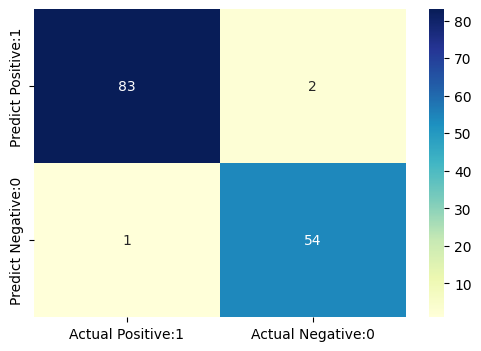

In [42]:
# Visualizando a matriz de confusão graficamente
plt.figure(figsize=(6,4))
cm_matrix = pd.DataFrame(data=cm7, columns=['Actual Positive:1', 'Actual Negative:0'], 
                                 index=['Predict Positive:1', 'Predict Negative:0'])
sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='YlGnBu')

### Métricas de Classificação

O relatório de classificação é outra forma de avaliar o desempenho do modelo de classificação. Ele exibe os scores de precisão, recall, f1 e support para o modelo. 


Podemos imprimir um relatório de classificação da seguinte forma:-


In [43]:
print(classification_report(y_test, y_pred_7))

              precision    recall  f1-score   support

           2       0.99      0.98      0.98        85
           4       0.96      0.98      0.97        55

    accuracy                           0.98       140
   macro avg       0.98      0.98      0.98       140
weighted avg       0.98      0.98      0.98       140



#### Acurácia do Modelo escolhido (k=7)

In [46]:
classification_accuracy = (TP + TN) / float(TP + TN + FP + FN)

print(f'Acurácia de Classificação (k=7) : {classification_accuracy:.4f}')

Acurácia de Classificação (k=7) : 0.9786


**Precisão**
A precisão pode ser definida como a porcentagem de resultados positivos previstos corretamente em relação a todos os resultados positivos previstos. Pode ser dada como a razão de verdadeiros positivos (TP) para a soma de verdadeiros positivos e falsos positivos (TP + FP).

Assim, a Precisão identifica a proporção de resultados positivos previstos corretamente. Ela está mais preocupada com a classe positiva do que com a classe negativa.

Matematicamente, a precisão pode ser definida como a razão de TP para (TP + FP).


In [47]:
# Mostrando a precisão
precision = TP / float(TP + FP)
print(f'Precisão : {precision:.4f}')

Precisão : 0.9765


**Curva ROC**
Outra ferramenta para medir o desempenho visual do modelo de classificação é a Curva ROC. Curva ROC significa Curva Característica de Operação do Recepto (Receiver Operating Characteristic Curve)r. Uma Curva ROC é um gráfico que mostra o desempenho de um modelo de classificação em vários níveis de limiar de classificação.

A Curva ROC plota a Taxa de Verdadeiros Positivos ( - True Positive RateTPR) contra a Taxa de Falsos Positivos (FPR) em vários níveis de limiar.

A Taxa de Verdadeiros Positivos (TPR) também é chamada de Recall. É definida como a razão de TP para (TP + FN).

A Taxa de Falsos Positivos (FPR) é definida como a razão de FP para (FP + TN).

Na Curva ROC, vamos focar na TPR (Taxa de Verdadeiros Positivos) e FPR (Taxa de Falsos Positivos) de um único ponto. Isso nos dará o desempenho geral da curva ROC, que consiste na TPR e FPR em vários níveis de

 limiar. Portanto, uma Curva ROC plota TPR versus FPR em diferentes níveis de limiar de classificação. Se reduzirmos os níveis de limiar, pode resultar em mais itens sendo classificados como positivos. Isso aumentará tanto os Verdadeiros Positivos (TP) quanto os Falsos Positivos (FP).


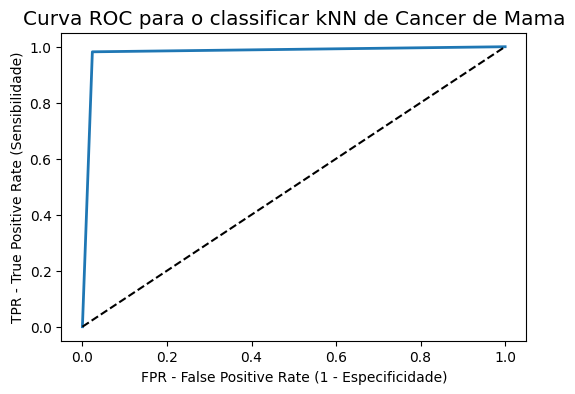

In [48]:
# Mostrando a curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_7, pos_label=4)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, linewidth=2)
plt.plot([0,1], [0,1], 'k--' )
plt.rcParams['font.size'] = 12
plt.title('Curva ROC para o classificar kNN de Cancer de Mama')
plt.xlabel('FPR - False Positive Rate (1 - Especificidade)')
plt.ylabel('TPR - True Positive Rate (Sensibilidade)')
plt.show()

**Curva ROC nos ajuda a escolher um nível de limiar que equilibra sensibilidade e especificidade para um contexto específico.**

**ROC AUC**
ROC AUC significa Característica de Operação do Receptor - Área sob a Curva. É uma técnica para comparar o desempenho do classificado

r. Nesta técnica, medimos a área sob a curva (AUC). Um classificador perfeito terá um ROC AUC igual a 1, enquanto um classificador puramente aleatório terá um ROC AUC igual a 0,5.

Portanto, o ROC AUC é a porcentagem do gráfico ROC que está abaixo da curva.


In [49]:
ROC_AUC = roc_auc_score(y_test, y_pred_7)
print(f'ROC AUC : {ROC_AUC:.4f}')

ROC AUC : 0.9791


**Interpretação**
ROC AUC é um resumo de um único número do desempenho do classificador. Quanto maior o valor, melhor o classificador.

O ROC AUC do nosso modelo se aproxima de 1. Portanto, podemos concluir que nosso classificador faz um bom trabalho em prever se é câncer benigno ou maligno.

## Fim do Projeto 15